In [250]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , mean_squared_error , precision_score , recall_score , f1_score , roc_auc_score
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler , LabelEncoder
from sklearn.ensemble import StackingClassifier

In [251]:
df = pd.read_csv('/content/Project_Phase1.csv')
df.head()

,syn_error_rate,connection_time,destination_same_source_port_rate,destination_different_server_rate,connection_status,connection_count,destination_server_different_host_rate,suspicious_activity,protocol,server_different_host_rate,...,destination_server_reset_error_rate,server_reset_error_rate,server_syn_error_rate,destination_bytes,guest_login,authentication_status,destination_host_count,destination_reset_error_rate,different_server_rate,class
0,0.0,0,0.01,0.00,SF,2,0.0,2,tcp,0.0,...,0.01,0.0,0.0,8314,0,1,87,0.01,0.00,anomaly
1,1.0,0,0.00,0.07,S0,242,0.0,0,tcp,0.0,...,0.00,0.0,1.0,0,0,0,255,0.00,0.07,anomaly
2,1.0,0,0.00,0.08,S0,234,0.0,0,tcp,0.0,...,0.00,0.0,1.0,0,0,0,255,0.00,0.06,anomaly
3,1.0,0,0.00,0.08,S0,140,0.0,0,tcp,0.0,...,0.00,0.0,1.0,0,0,0,255,0.00,0.06,anomaly
4,1.0,0,0.00,0.07,S0,126,0.0,0,tcp,0.0,...,0.00,0.0,1.0,0,0,0,255,0.00,0.06,anomaly


In [252]:
df.duplicated().sum()

np.int64(0)

In [253]:
df.isnull().sum()

,0
syn_error_rate,0
connection_time,0
destination_same_source_port_rate,0
destination_different_server_rate,0
connection_status,0
connection_count,0
destination_server_different_host_rate,0
suspicious_activity,0
protocol,0
server_different_host_rate,0


In [254]:
df.describe()

,syn_error_rate,connection_time,destination_same_source_port_rate,destination_different_server_rate,connection_count,destination_server_different_host_rate,suspicious_activity,server_different_host_rate,destination_server_syn_error_rate,destination_host_server_count,...,server_request_count,destination_server_reset_error_rate,server_reset_error_rate,server_syn_error_rate,destination_bytes,guest_login,authentication_status,destination_host_count,destination_reset_error_rate,different_server_rate
count,14036.000000,14036.000000,14036.000000,14036.000000,14036.000000,14036.000000,14036.000000,14036.000000,14036.000000,14036.000000,...,14036.000000,14036.000000,14036.000000,14036.000000,1.403600e+04,14036.000000,14036.000000,14036.00000,14036.000000,14036.000000
mean,0.039788,184.191294,0.122315,0.044255,28.048019,0.025829,0.221288,0.122144,0.032572,182.678755,...,27.400328,0.048468,0.049172,0.037901,4.226110e+03,0.012183,0.681177,151.48625,0.050431,0.032923
std,0.183392,1448.604080,0.257433,0.135233,63.798968,0.071390,2.327768,0.266557,0.168483,97.214193,...,60.297916,0.200340,0.211871,0.179243,6.833466e+04,0.109706,0.466037,101.76511,0.203809,0.151932
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,93.000000,...,2.000000,0.000000,0.000000,0.000000,7.200000e+01,0.000000,0.000000,43.00000,0.000000,0.000000
50%,0.000000,0.000000,0.010000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,254.000000,...,6.000000,0.000000,0.000000,0.000000,3.465000e+02,0.000000,1.000000,168.00000,0.000000,0.000000
75%,0.000000,0.000000,0.080000,0.020000,15.000000,0.030000,0.000000,0.100000,0.000000,255.000000,...,18.000000,0.000000,0.000000,0.000000,1.924250e+03,0.000000,1.000000,255.00000,0.000000,0.000000
max,1.000000,41476.000000,1.000000,1.000000,511.000000,1.000000,77.000000,1.000000,1.000000,255.000000,...,511.000000,1.000000,1.000000,1.000000,5.131424e+06,1.000000,1.000000,255.00000,1.000000,1.000000


In [255]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14036 entries, 0 to 14035
Data columns (total 31 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   syn_error_rate                          14036 non-null  float64
 1   connection_time                         14036 non-null  int64  
 2   destination_same_source_port_rate       14036 non-null  float64
 3   destination_different_server_rate       14036 non-null  float64
 4   connection_status                       14036 non-null  object 
 5   connection_count                        14036 non-null  int64  
 6   destination_server_different_host_rate  14036 non-null  float64
 7   suspicious_activity                     14036 non-null  int64  
 8   protocol                                14036 non-null  object 
 9   server_different_host_rate              14036 non-null  float64
 10  destination_server_syn_error_rate       14036 non-null  fl

In [256]:
df['connection_status'].unique()

array(['SF', 'S0', 'REJ', 'RSTO', 'RSTR', 'RSTOS0', 'S1', 'S3', 'S2',
       'OTH'], dtype=object)

In [257]:
df.drop(columns=['connection_status' , 'service_type'] , inplace = True)

In [258]:
label_encoder = LabelEncoder()
df['class'] = label_encoder.fit_transform(df['class'])
df['protocol'] = label_encoder.fit_transform(df['protocol'])

In [259]:
# df = pd.get_dummies(df , columns = ['connection_status' , 'protocol' , 'service_type']).astype(float)

In [260]:
df

,syn_error_rate,connection_time,destination_same_source_port_rate,destination_different_server_rate,connection_count,destination_server_different_host_rate,suspicious_activity,protocol,server_different_host_rate,destination_server_syn_error_rate,...,destination_server_reset_error_rate,server_reset_error_rate,server_syn_error_rate,destination_bytes,guest_login,authentication_status,destination_host_count,destination_reset_error_rate,different_server_rate,class
0,0.0,0,0.01,0.00,2,0.00,2,1,0.00,0.0,...,0.01,0.0,0.00,8314,0,1,87,0.01,0.00,0
1,1.0,0,0.00,0.07,242,0.00,0,1,0.00,1.0,...,0.00,0.0,1.00,0,0,0,255,0.00,0.07,0
2,1.0,0,0.00,0.08,234,0.00,0,1,0.00,1.0,...,0.00,0.0,1.00,0,0,0,255,0.00,0.06,0
3,1.0,0,0.00,0.08,140,0.00,0,1,0.00,1.0,...,0.00,0.0,1.00,0,0,0,255,0.00,0.06,0
4,1.0,0,0.00,0.07,126,0.00,0,1,0.00,1.0,...,0.00,0.0,1.00,0,0,0,255,0.00,0.06,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14031,0.0,0,0.12,0.07,1,0.07,0,1,0.00,0.0,...,0.00,0.0,0.00,0,0,0,58,0.00,0.00,1
14032,0.0,0,0.00,0.00,19,0.00,0,1,0.00,0.0,...,0.00,0.0,0.00,2486,0,1,255,0.00,0.00,1
14033,0.0,29,0.00,0.02,1,0.00,6,1,0.00,0.0,...,0.10,0.0,0.00,1063,1,1,255,0.03,0.00,1
14034,0.0,1,0.08,0.17,1,0.00,0,1,1.00,0.0,...,0.00,0.0,0.00,333,0,1,12,0.00,0.00,1


In [261]:
target = df['class']
target

,class
0,0
1,0
2,0
3,0
4,0
...,...
14031,1
14032,1
14033,1
14034,1


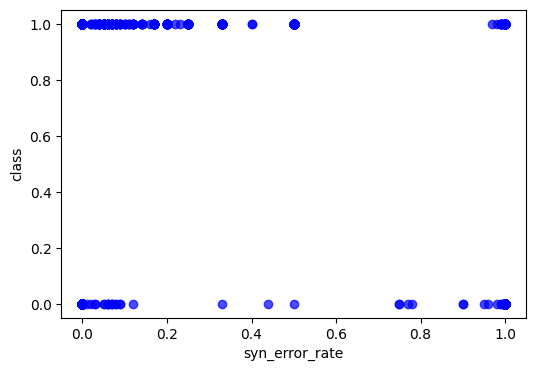

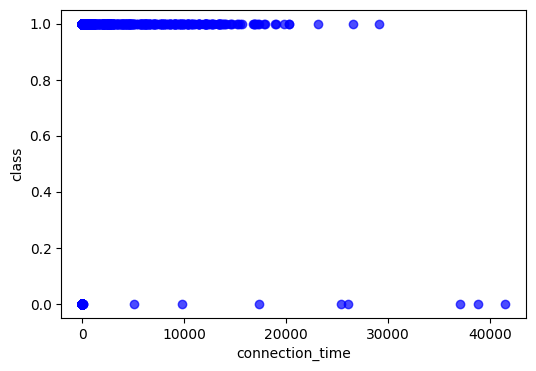

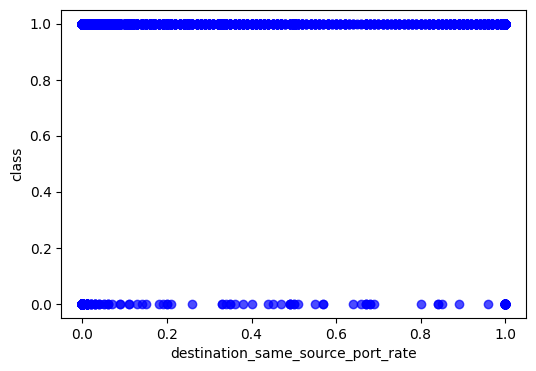

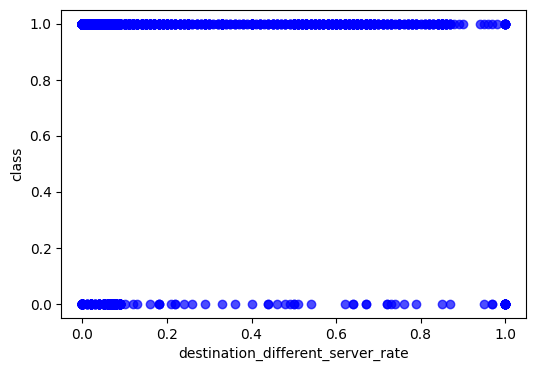

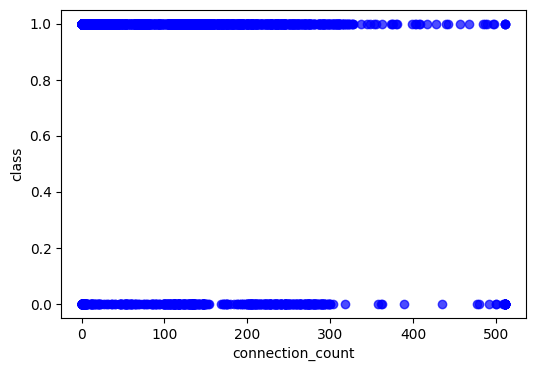

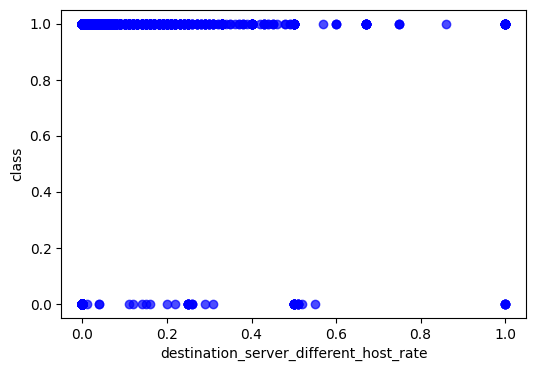

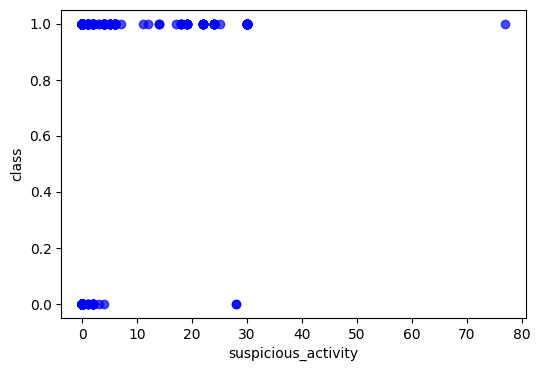

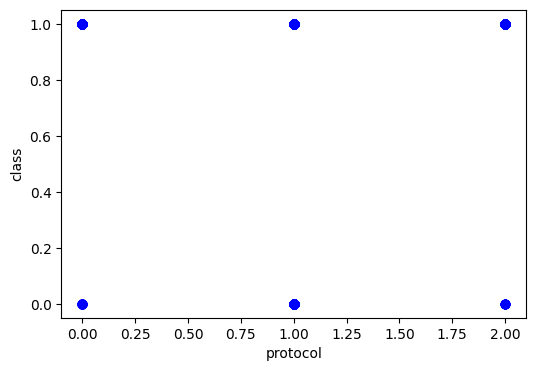

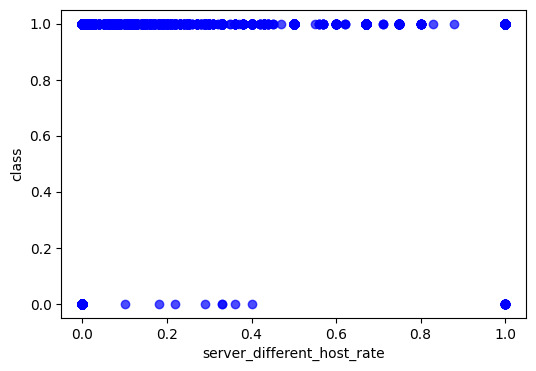

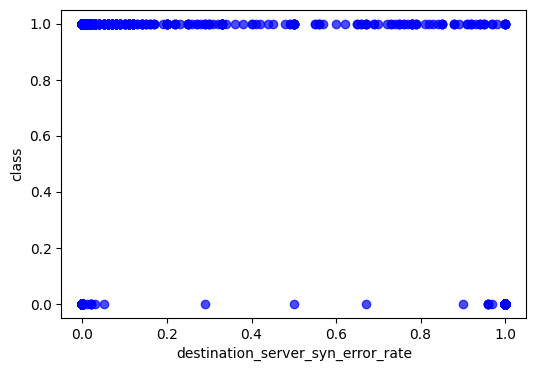

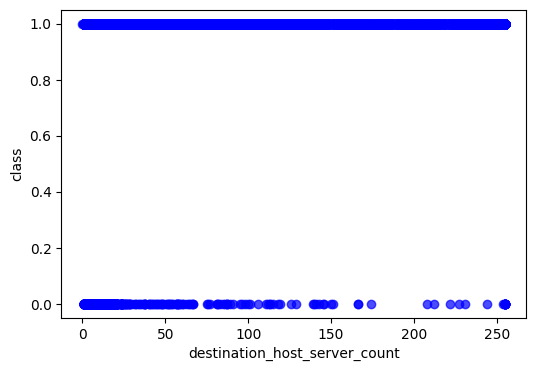

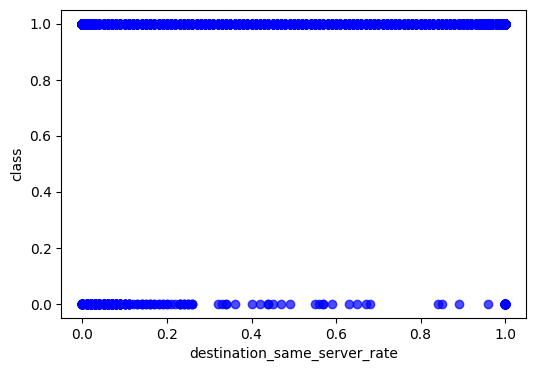

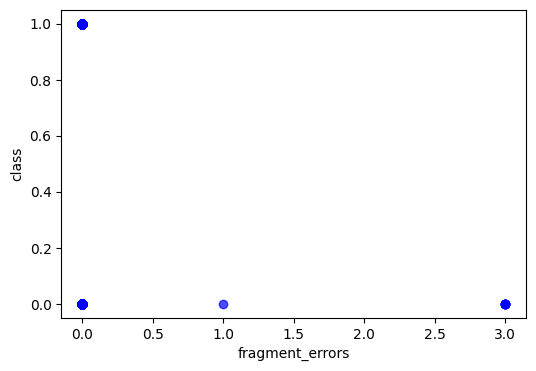

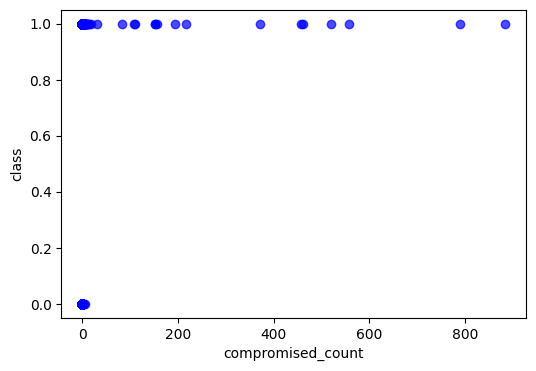

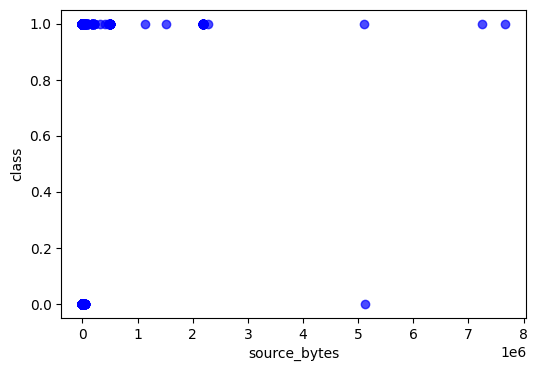

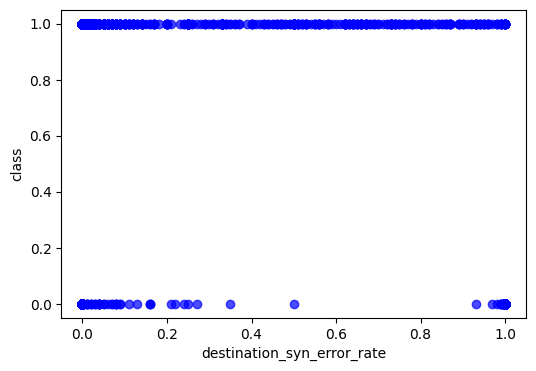

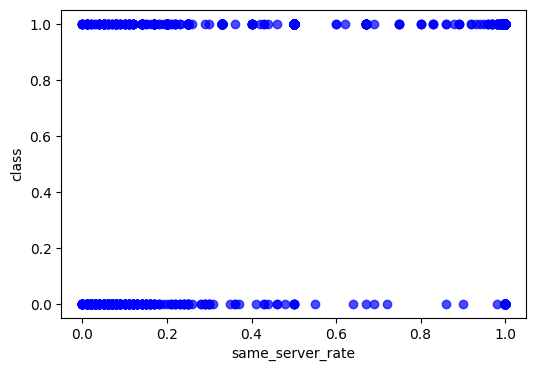

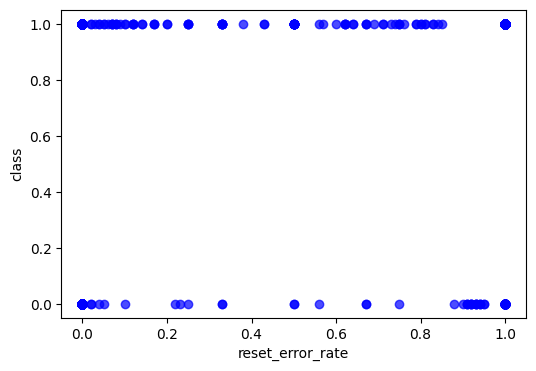

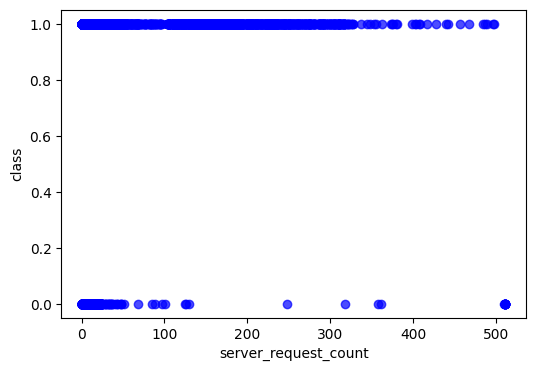

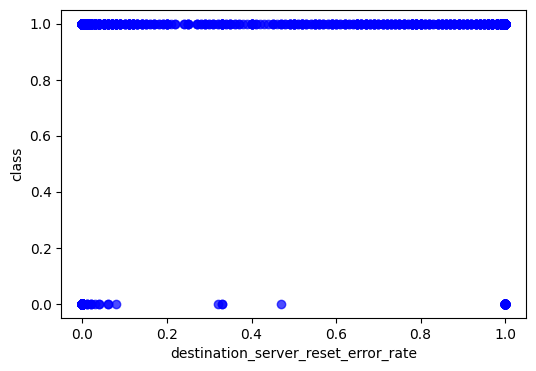

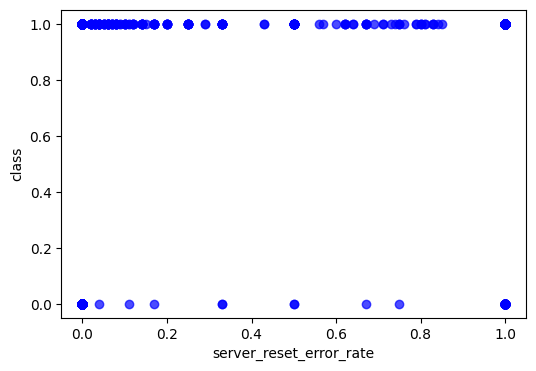

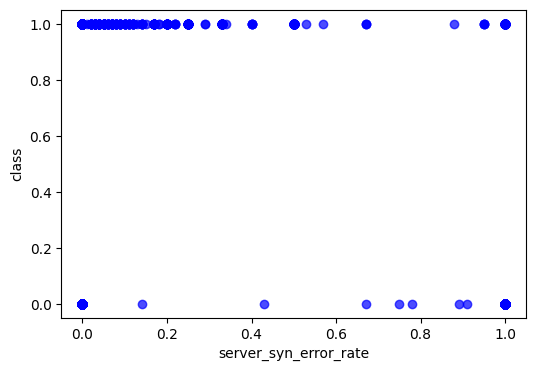

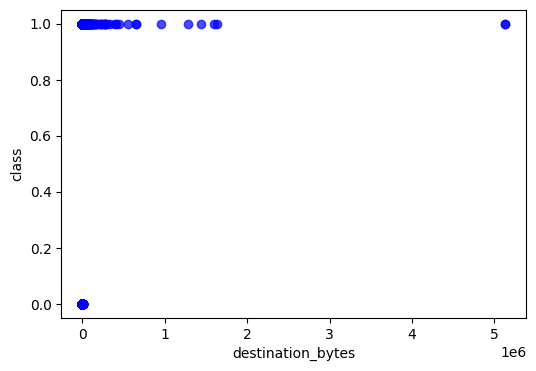

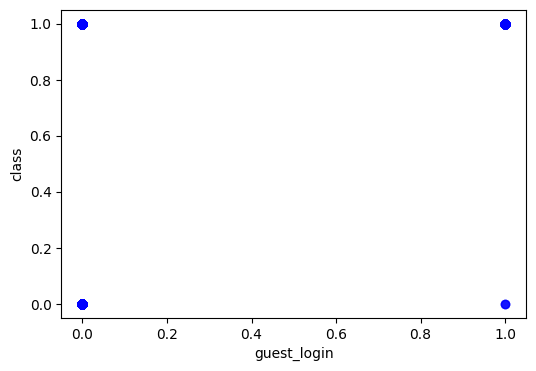

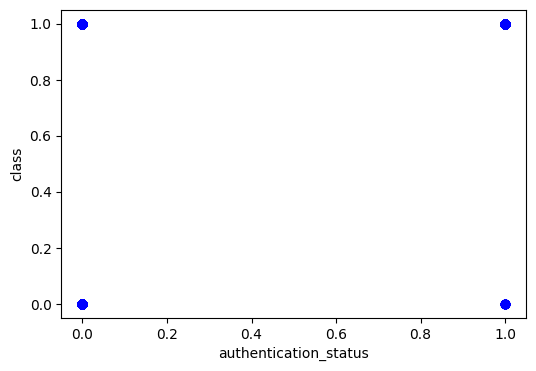

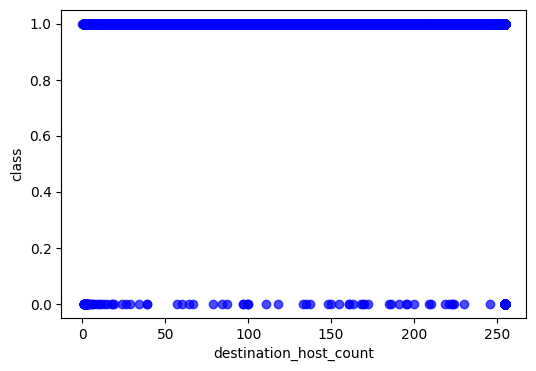

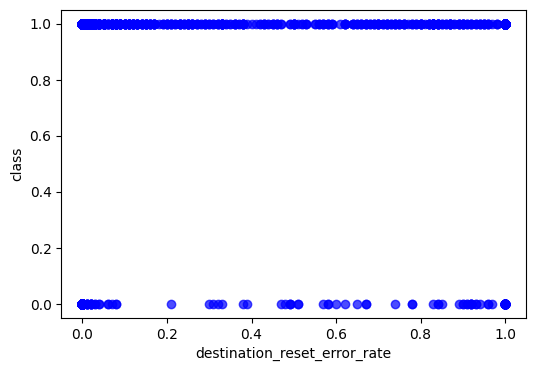

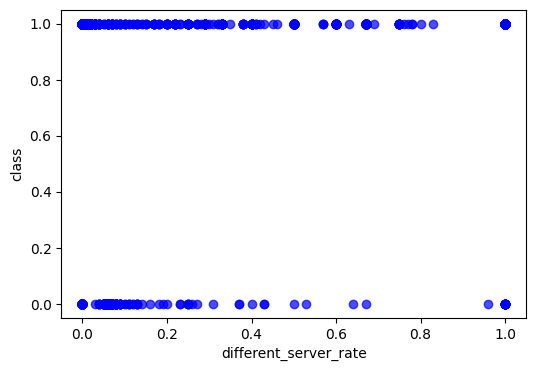

In [262]:
for column in df.columns:
    if column != 'class':
        plt.figure(figsize=(6, 4))
        plt.scatter(df[column], df['class'], color='blue', alpha=0.7)
        plt.xlabel(column)
        plt.ylabel('class')
        # plt.grid(True)
        plt.show()

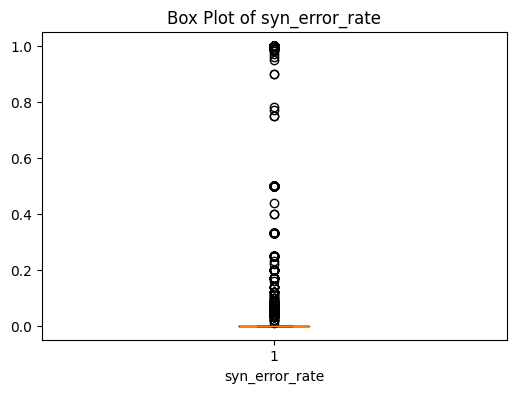

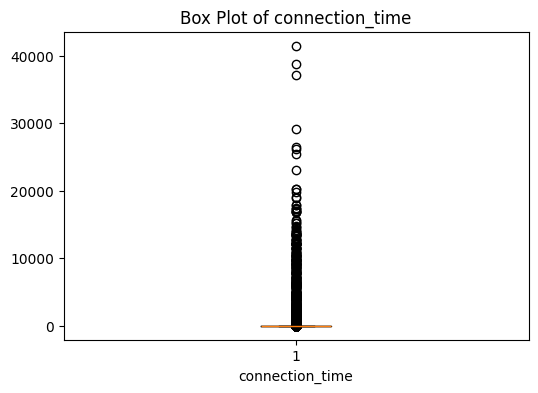

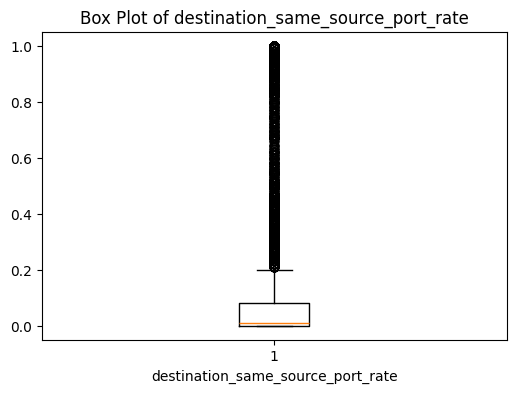

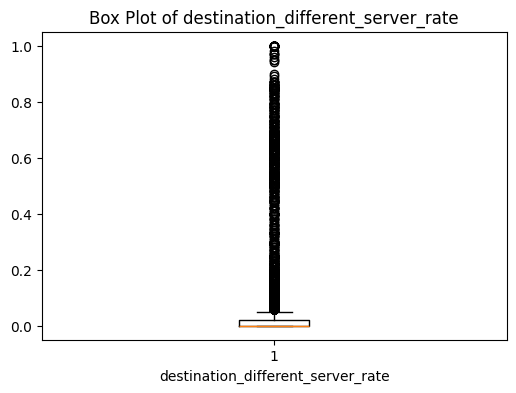

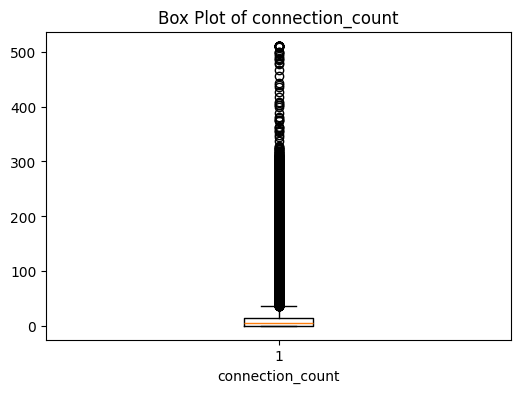

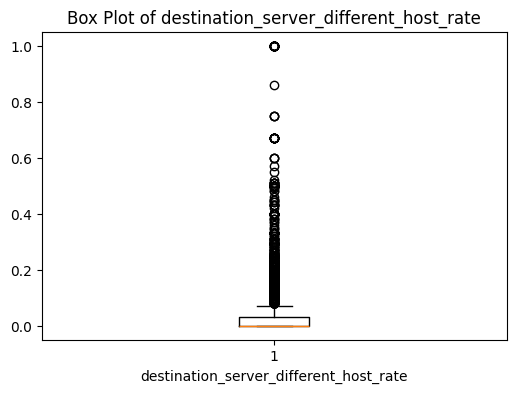

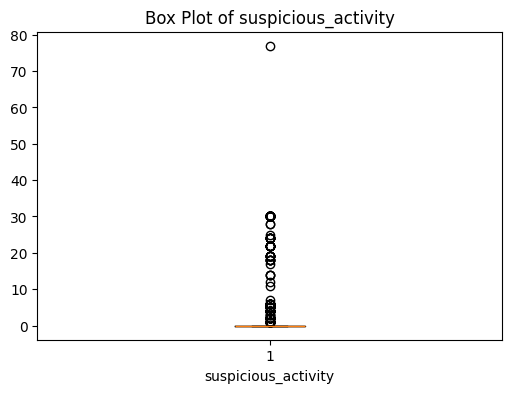

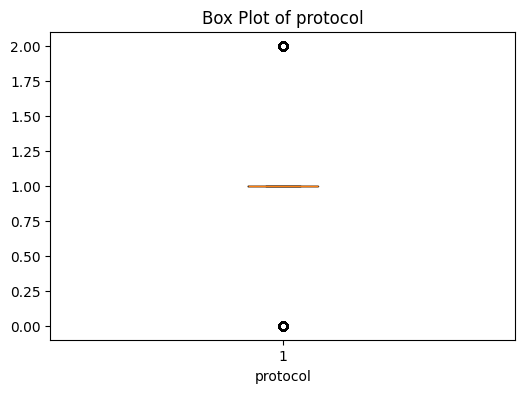

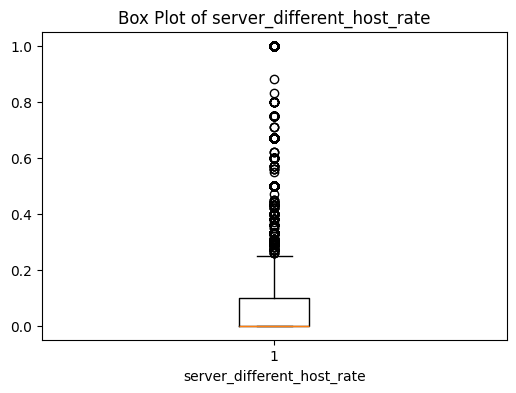

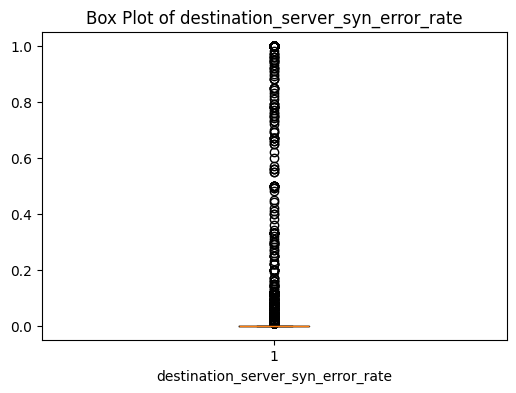

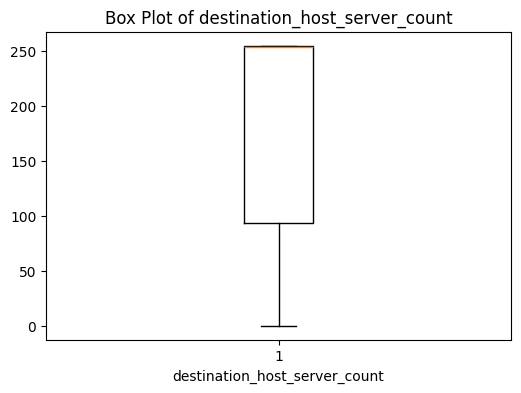

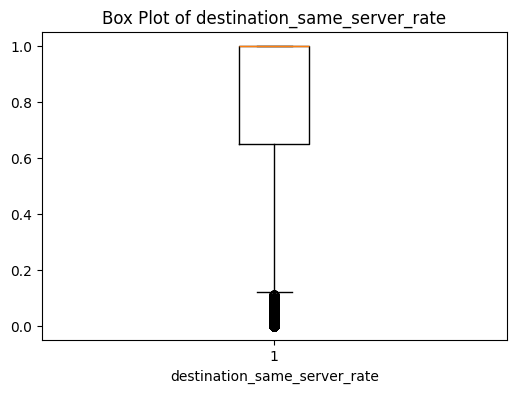

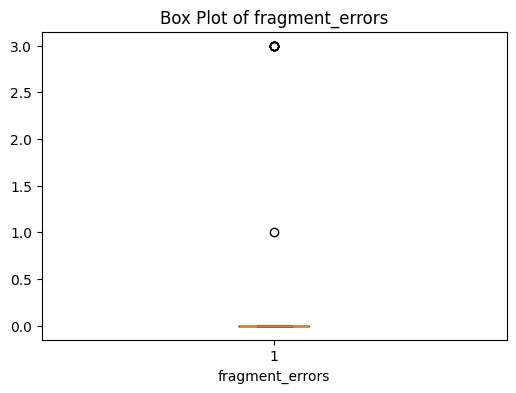

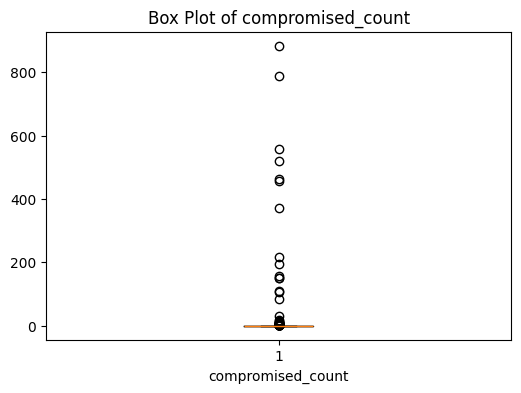

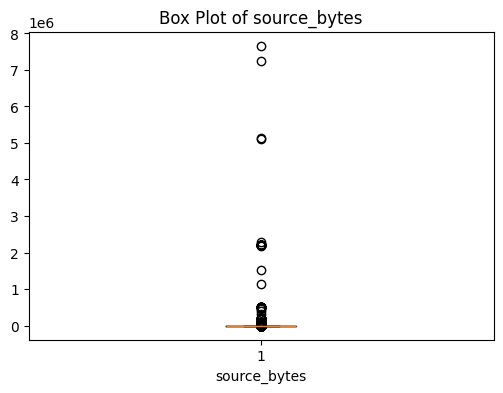

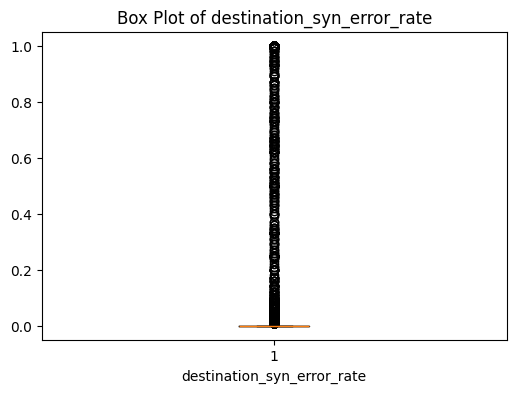

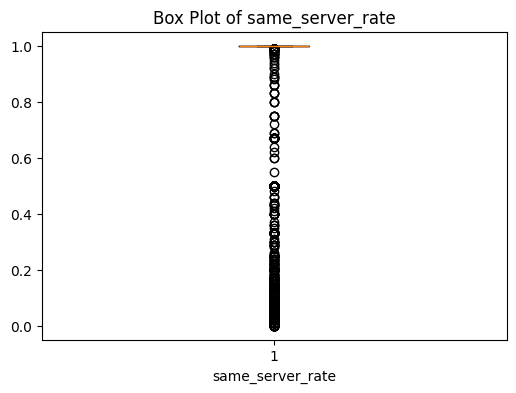

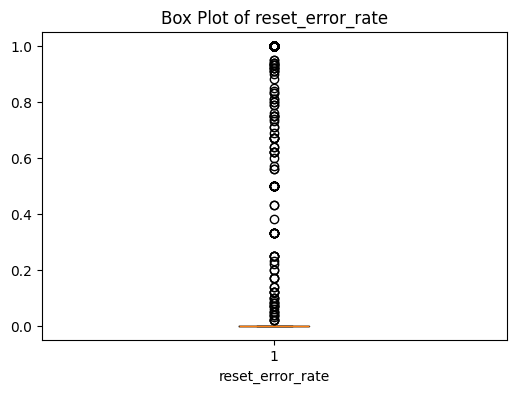

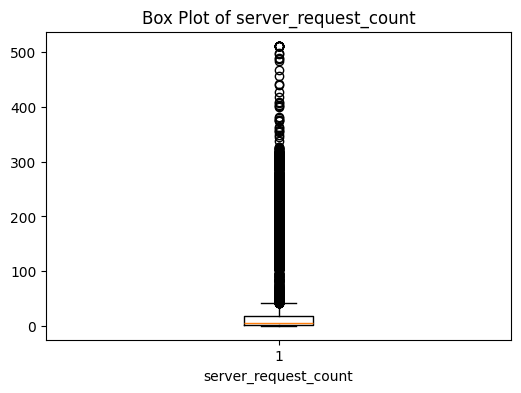

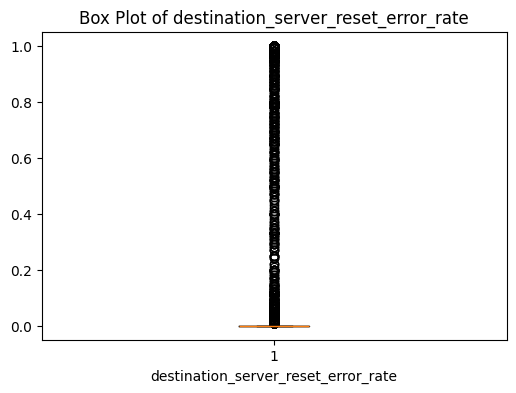

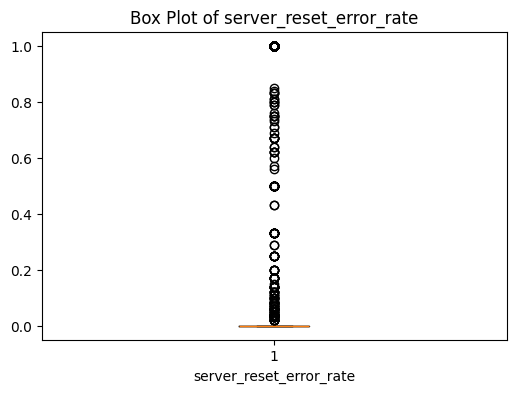

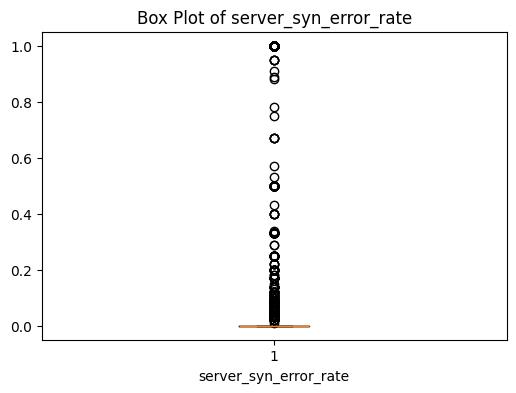

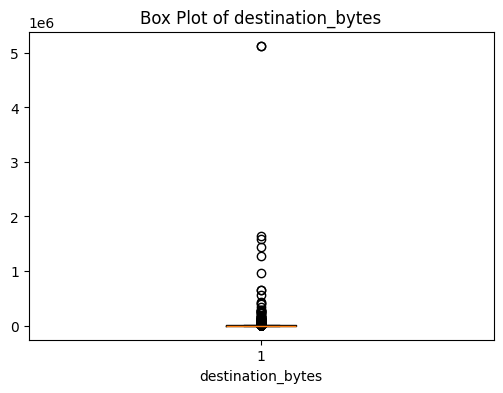

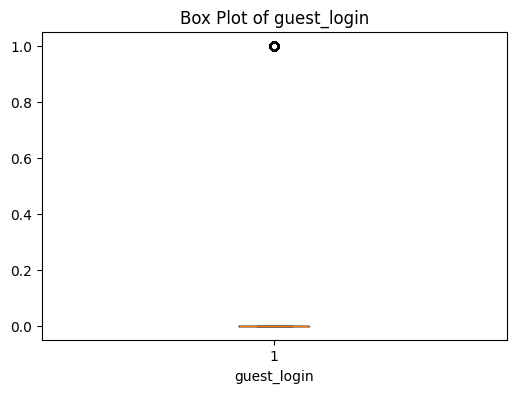

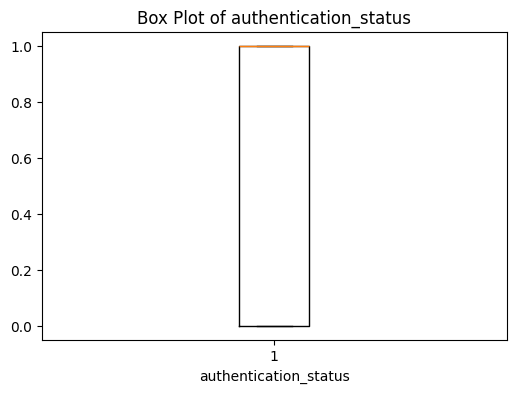

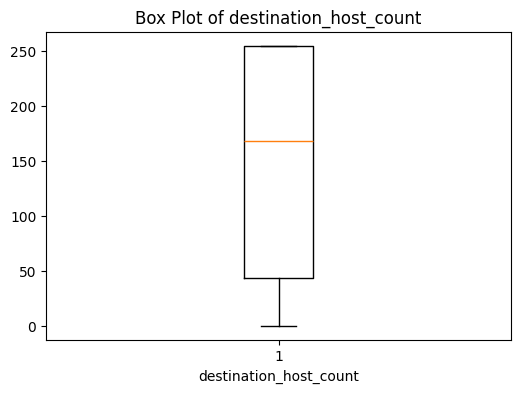

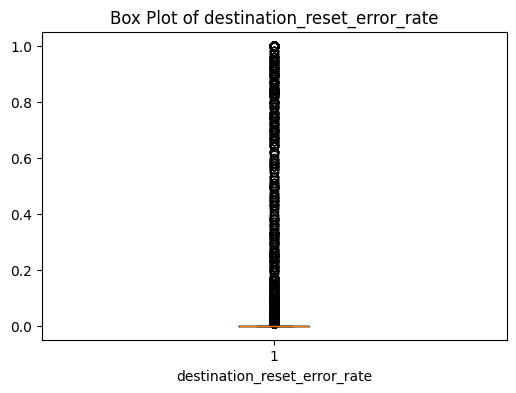

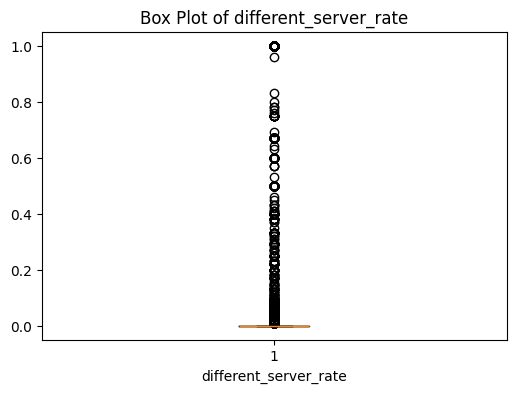

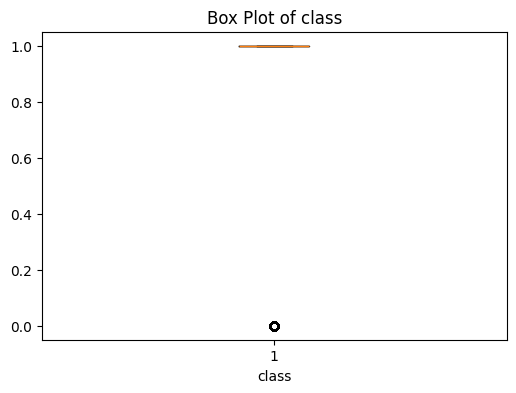

In [263]:
for column in df.columns:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[column])
    plt.title(f'Box Plot of {column}')
    plt.xlabel(column)
    plt.show()

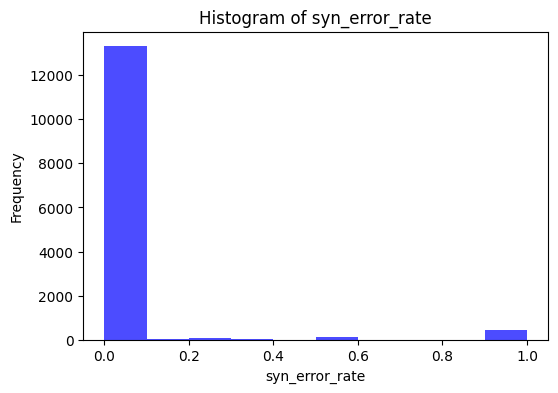

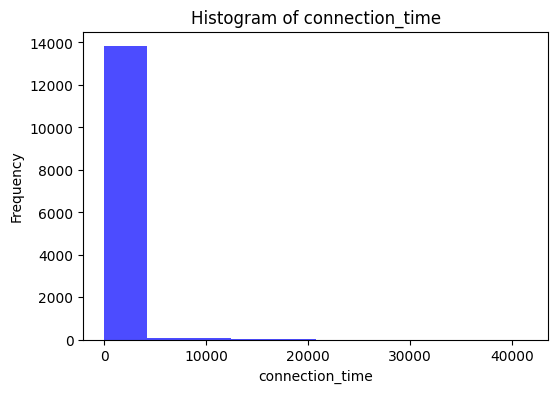

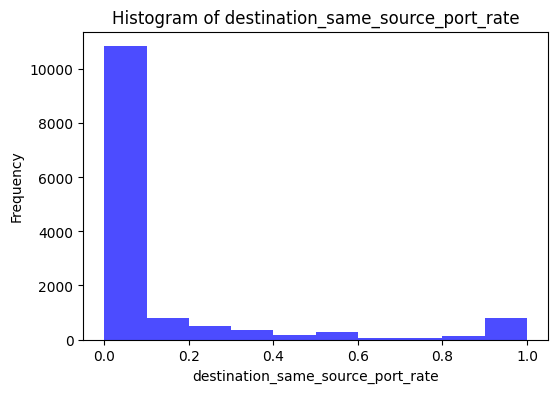

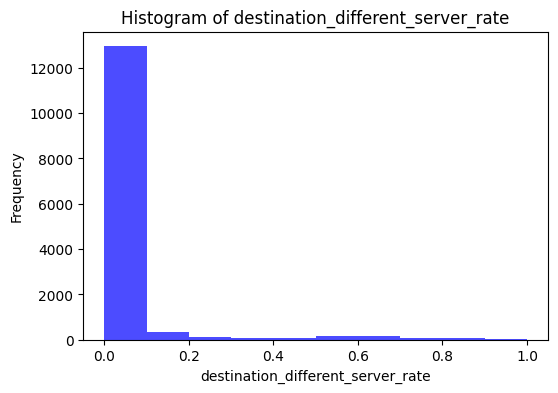

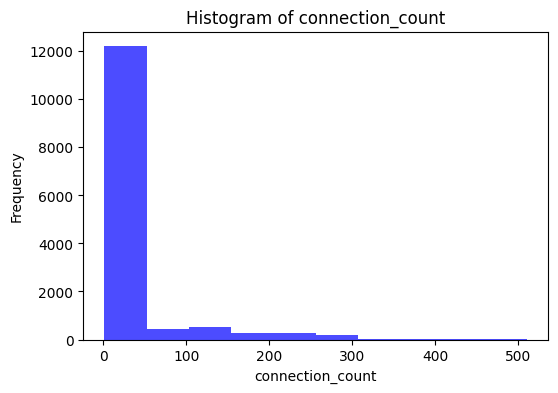

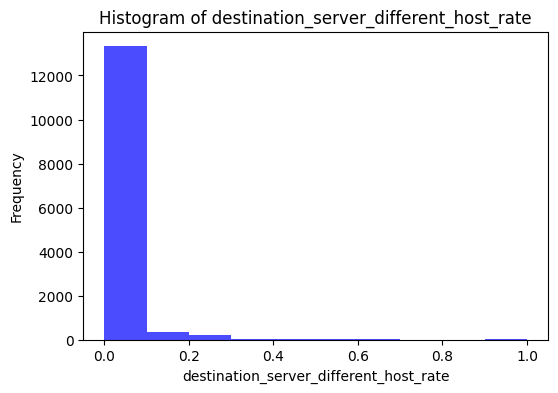

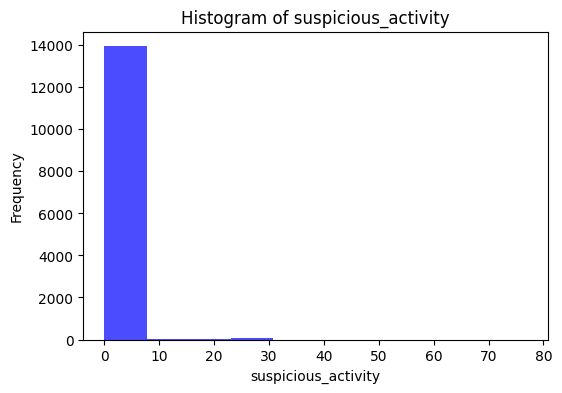

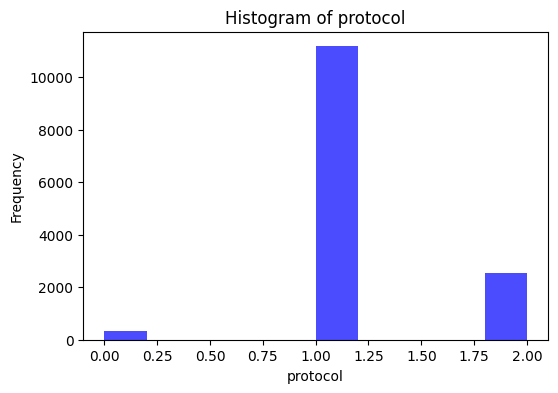

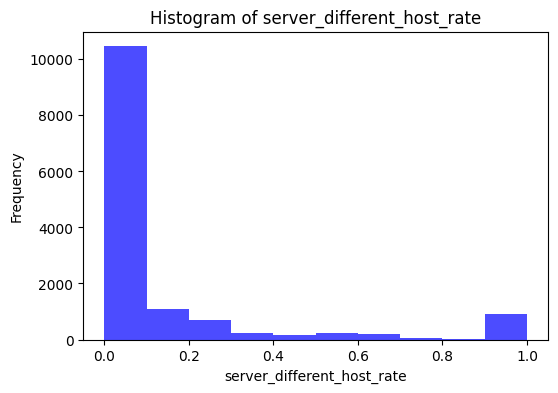

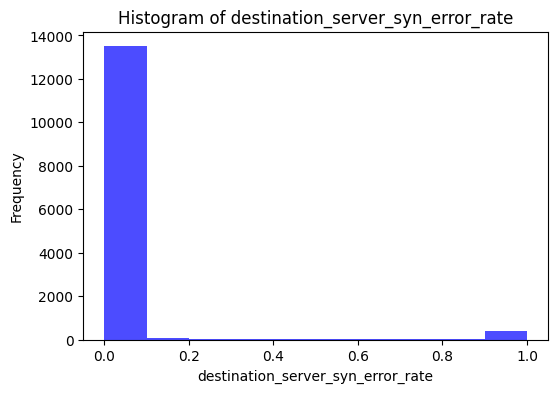

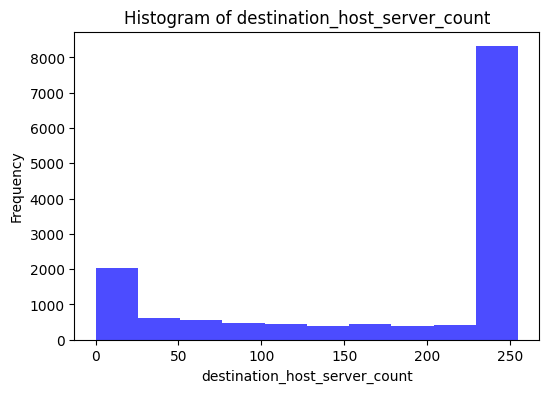

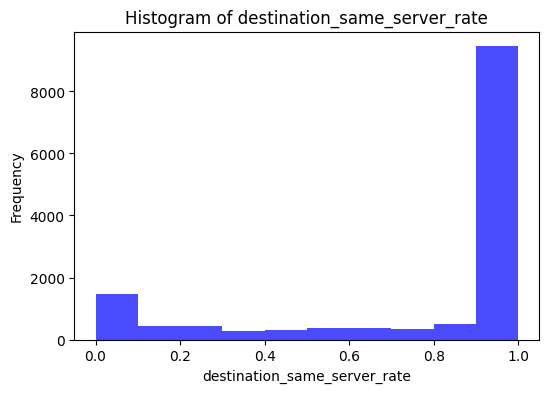

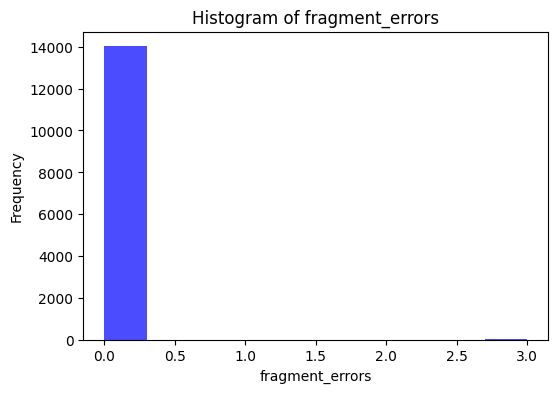

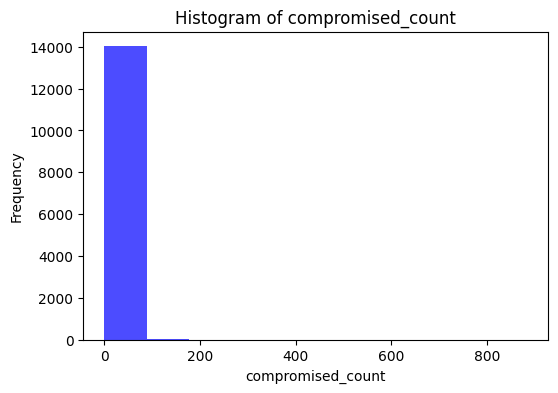

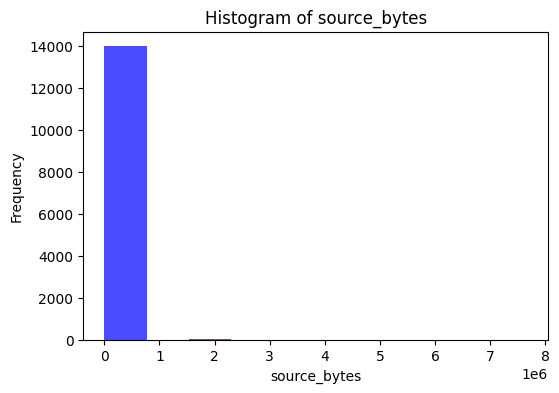

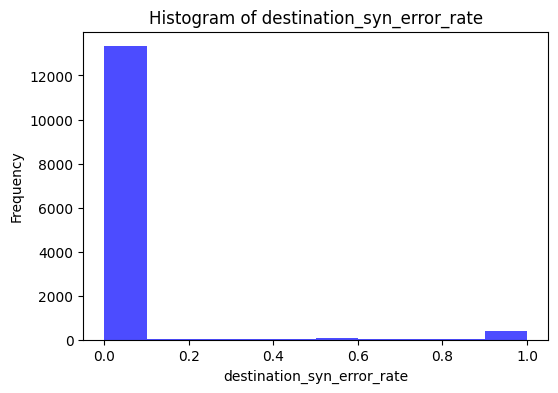

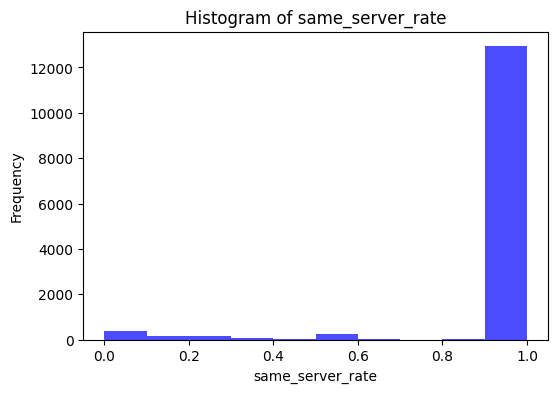

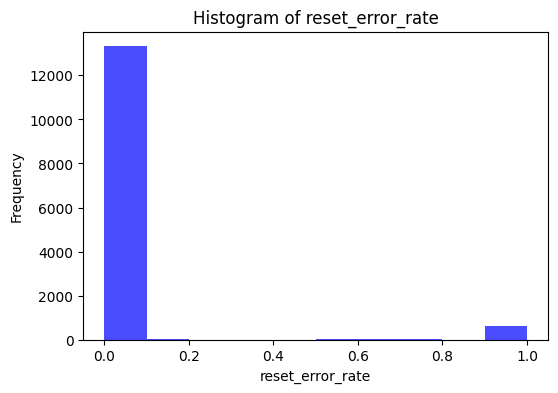

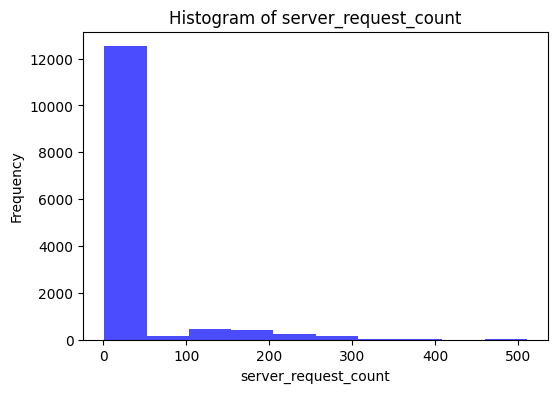

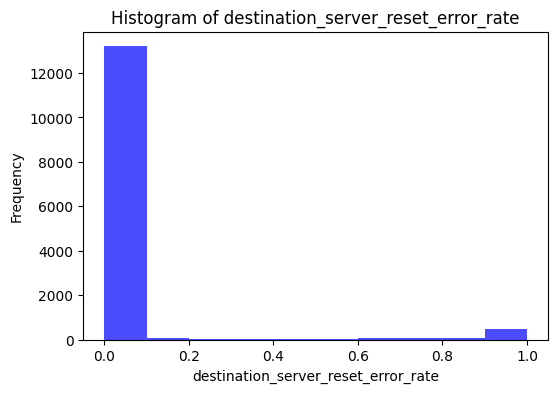

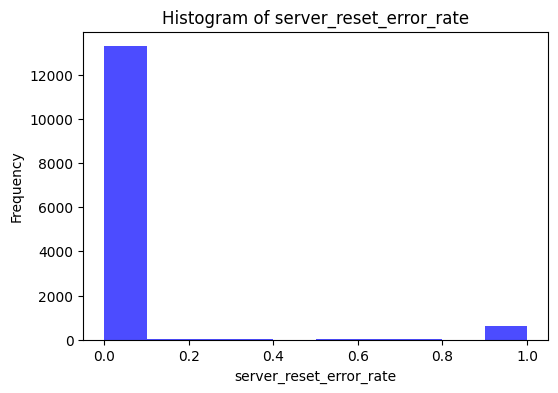

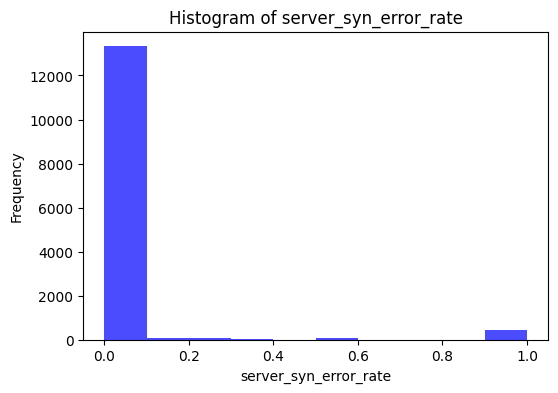

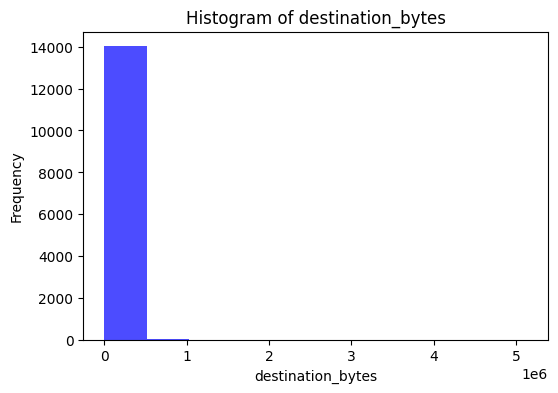

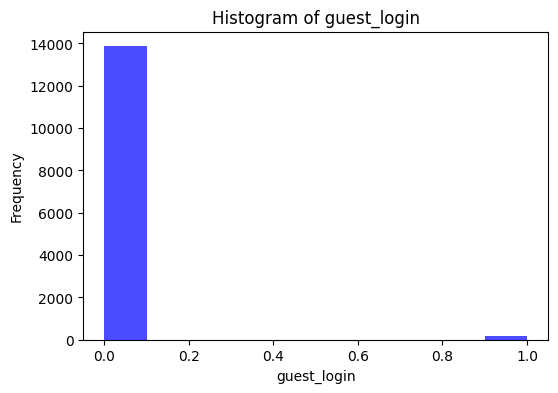

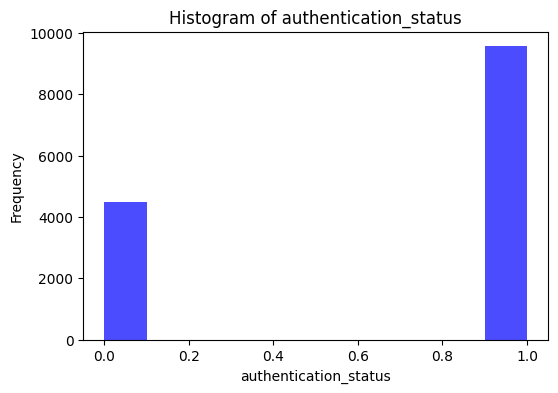

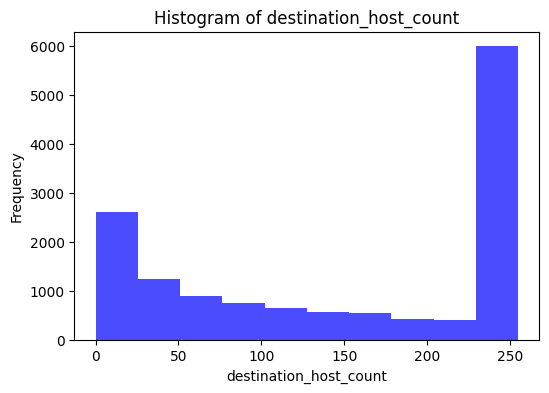

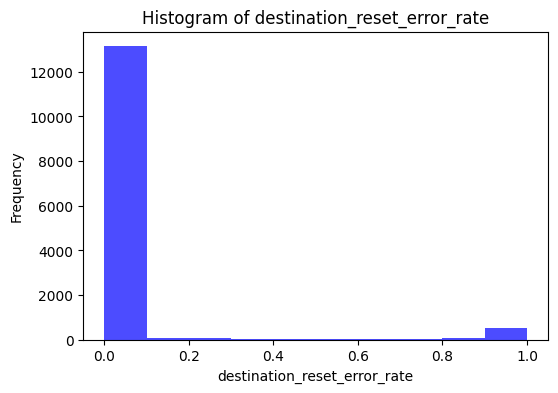

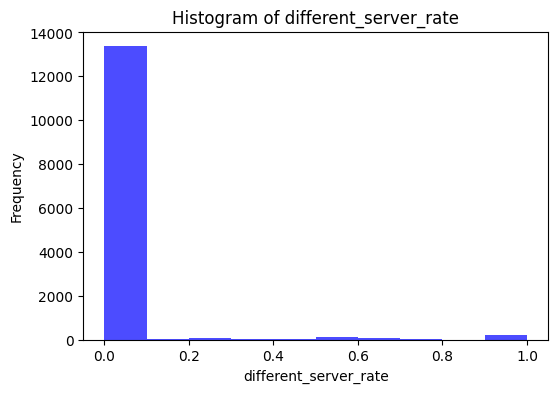

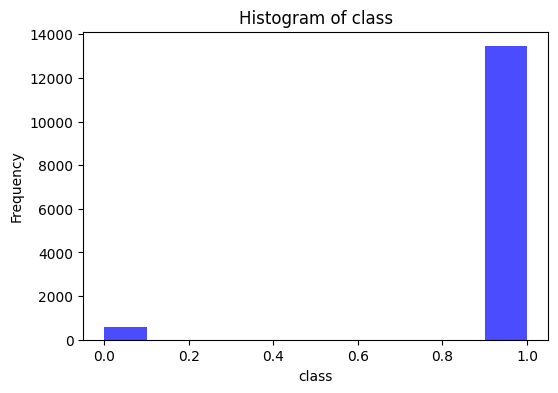

In [264]:
for column in df.columns:
    plt.figure(figsize=(6, 4))
    plt.hist(df[column], bins=10, color='blue', alpha=0.7)
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

In [265]:
correlation_matrix = df.corr()
correlation_matrix

,syn_error_rate,connection_time,destination_same_source_port_rate,destination_different_server_rate,connection_count,destination_server_different_host_rate,suspicious_activity,protocol,server_different_host_rate,destination_server_syn_error_rate,...,destination_server_reset_error_rate,server_reset_error_rate,server_syn_error_rate,destination_bytes,guest_login,authentication_status,destination_host_count,destination_reset_error_rate,different_server_rate,class
syn_error_rate,1.000000,-0.025722,-0.060082,0.037308,0.291691,-0.037862,-0.017207,-0.079886,-0.053885,0.823675,...,-0.030593,-0.046146,0.960373,-0.001429,-0.024095,-0.205602,0.110198,-0.035989,0.041586,-0.655461
connection_time,-0.025722,1.000000,0.238938,0.366768,-0.051821,-0.019542,0.021545,0.123189,-0.056773,0.019307,...,0.073712,0.085749,-0.025591,0.068087,-0.011370,-0.101420,0.063418,0.023716,0.080576,-0.022855
destination_same_source_port_rate,-0.060082,0.238938,1.000000,0.427771,-0.062627,0.186979,-0.027778,0.095265,-0.033871,-0.077422,...,0.048307,0.050899,-0.065100,-0.016364,-0.035108,-0.257843,-0.199762,0.061461,0.126341,-0.030709
destination_different_server_rate,0.037308,0.366768,0.427771,1.000000,-0.005647,-0.041857,0.035663,0.223494,-0.047520,0.035629,...,0.038639,0.036189,0.032709,-0.006650,0.037855,-0.233882,0.088281,0.070973,0.286487,-0.119493
connection_count,0.291691,-0.051821,-0.062627,-0.005647,1.000000,-0.135053,-0.040055,0.399387,-0.170749,0.321161,...,0.018810,0.014167,0.288976,-0.022819,-0.046942,-0.461982,0.340381,0.015099,0.016517,-0.410791
destination_server_different_host_rate,-0.037862,-0.019542,0.186979,-0.041857,-0.135053,1.000000,-0.023176,-0.207234,0.057982,-0.039194,...,0.277205,0.224919,-0.035331,-0.003693,-0.027262,-0.055632,-0.365872,0.258163,-0.043483,-0.032599
suspicious_activity,-0.017207,0.021545,-0.027778,0.035663,-0.040055,-0.023176,1.000000,-0.035422,-0.032615,-0.012893,...,-0.015096,-0.020291,-0.016191,0.004336,0.795499,0.064711,-0.002033,-0.010969,-0.000082,0.005336
protocol,-0.079886,0.123189,0.095265,0.223494,0.399387,-0.207234,-0.035422,1.000000,-0.076526,-0.072035,...,-0.090146,-0.086478,-0.078789,-0.022524,-0.041379,-0.544624,0.297251,-0.084981,0.014572,0.107307
server_different_host_rate,-0.053885,-0.056773,-0.033871,-0.047520,-0.170749,0.057982,-0.032615,-0.076526,1.000000,-0.075475,...,0.043303,0.053474,-0.063632,-0.013051,-0.041144,0.101155,-0.137449,0.058123,-0.052602,0.048721
destination_server_syn_error_rate,0.823675,0.019307,-0.077422,0.035629,0.321161,-0.039194,-0.012893,-0.072035,-0.075475,1.000000,...,-0.040229,-0.039761,0.847957,0.048315,-0.020430,-0.212474,0.153676,-0.040876,0.044811,-0.716601


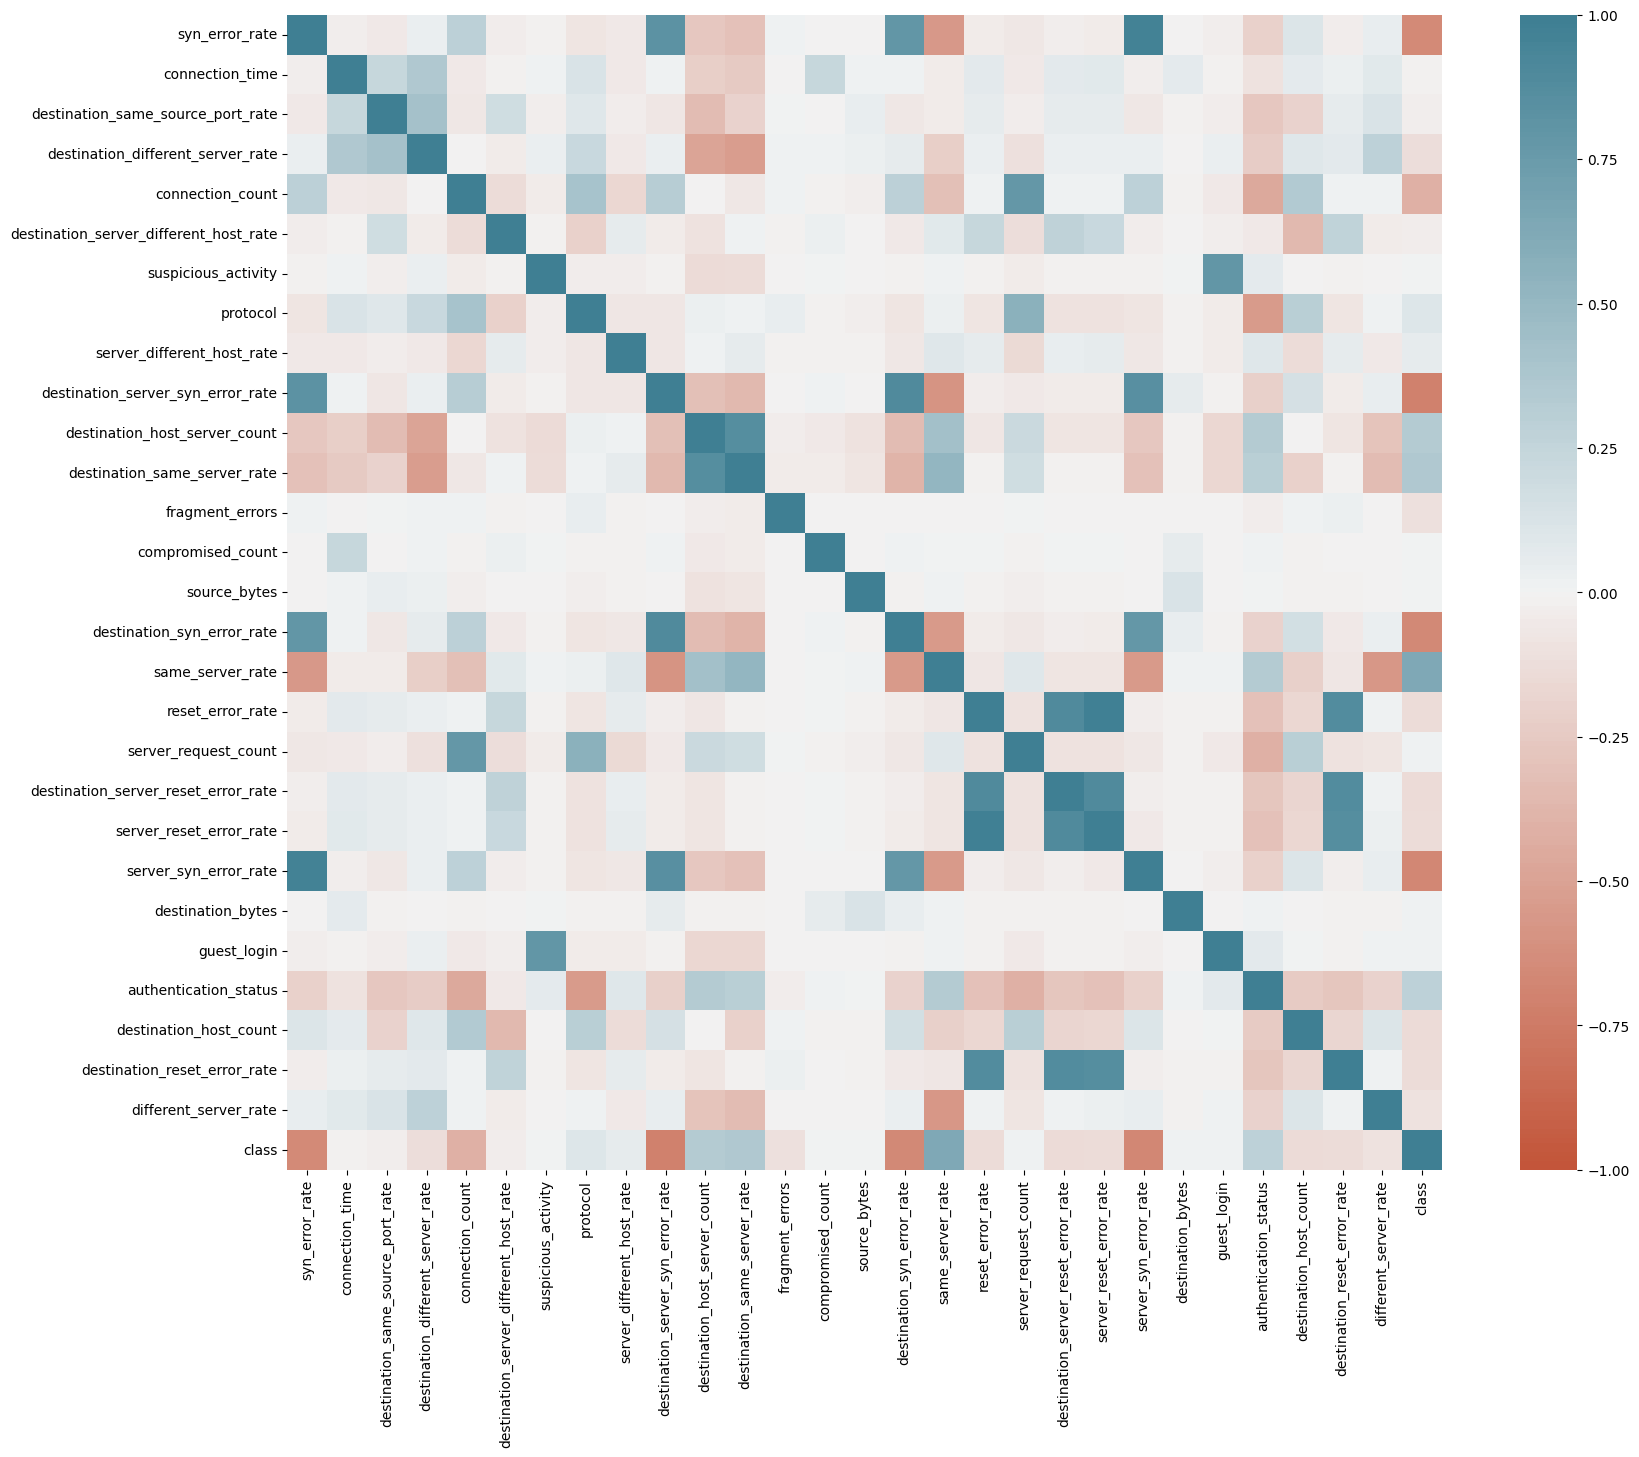

In [266]:
plt.subplots(figsize=(20,15))
w = sns.heatmap(
    correlation_matrix,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True
    )

In [267]:
highly_correlated = correlation_matrix['class'].abs().sort_values(ascending = False)
columns_to_leave = highly_correlated[1:21].index.to_list()
columns_to_drop = highly_correlated[22:].index.to_list()
columns_to_leave

['destination_server_syn_error_rate',
 'server_syn_error_rate',
 'destination_syn_error_rate',
 'syn_error_rate',
 'same_server_rate',
 'connection_count',
 'destination_same_server_rate',
 'destination_host_server_count',
 'authentication_status',
 'destination_host_count',
 'destination_server_reset_error_rate',
 'reset_error_rate',
 'destination_reset_error_rate',
 'server_reset_error_rate',
 'destination_different_server_rate',
 'fragment_errors',
 'protocol',
 'different_server_rate',
 'server_different_host_rate',
 'destination_server_different_host_rate']

In [268]:
columns_to_plot = highly_correlated[1:6].index.to_list()
# columns_to_plot_df = pd.DataFrame(columns_to_plot)
# columns_to_plot_df

In [269]:
import seaborn as sns

In [270]:
# plt.figure(figsize=(10, 6))
# sns.scatterplot(data=columns_to_plot_df, x='index', y='Value', hue='Column', palette='Set1')

In [271]:
# plt.figure(figsize=(10, 6))
# columns_to_plot_df.plot(kind='scatter', x=columns_to_plot_df.index, y=columns_to_plot_df.columns[0], color=['red', 'blue', 'green', 'orange', 'purple'])

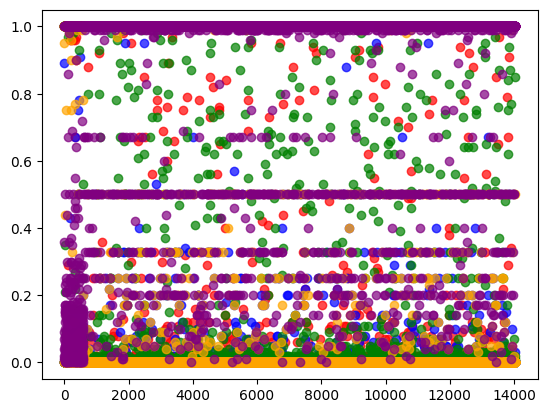

In [272]:
colors = ['red', 'blue', 'green', 'orange', 'purple']

for i, column in enumerate(columns_to_plot):
    plt.scatter(df.index, df[column], color=colors[i], label=column, alpha=0.7)

In [273]:
df_reduced = df.drop(columns=columns_to_drop)

In [274]:
df_reduced

,syn_error_rate,destination_same_source_port_rate,destination_different_server_rate,connection_count,destination_server_different_host_rate,protocol,server_different_host_rate,destination_server_syn_error_rate,destination_host_server_count,destination_same_server_rate,...,same_server_rate,reset_error_rate,destination_server_reset_error_rate,server_reset_error_rate,server_syn_error_rate,authentication_status,destination_host_count,destination_reset_error_rate,different_server_rate,class
0,0.0,0.01,0.00,2,0.00,1,0.00,0.0,87,1.00,...,1.00,0.0,0.01,0.0,0.00,1,87,0.01,0.00,0
1,1.0,0.00,0.07,242,0.00,1,0.00,1.0,6,0.02,...,0.02,0.0,0.00,0.0,1.00,0,255,0.00,0.07,0
2,1.0,0.00,0.08,234,0.00,1,0.00,1.0,12,0.05,...,0.07,0.0,0.00,0.0,1.00,0,255,0.00,0.06,0
3,1.0,0.00,0.08,140,0.00,1,0.00,1.0,1,0.00,...,0.01,0.0,0.00,0.0,1.00,0,255,0.00,0.06,0
4,1.0,0.00,0.07,126,0.00,1,0.00,1.0,11,0.04,...,0.09,0.0,0.00,0.0,1.00,0,255,0.00,0.06,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14031,0.0,0.12,0.07,1,0.07,1,0.00,0.0,27,0.12,...,1.00,0.0,0.00,0.0,0.00,0,58,0.00,0.00,1
14032,0.0,0.00,0.00,19,0.00,1,0.00,0.0,255,1.00,...,1.00,0.0,0.00,0.0,0.00,1,255,0.00,0.00,1
14033,0.0,0.00,0.02,1,0.00,1,0.00,0.0,60,0.24,...,1.00,0.0,0.10,0.0,0.00,1,255,0.03,0.00,1
14034,0.0,0.08,0.17,1,0.00,1,1.00,0.0,11,0.92,...,1.00,0.0,0.00,0.0,0.00,1,12,0.00,0.00,1


In [275]:
def detect_outliers(column):
  Q1 = column.quantile(0.25)
  Q3 = column.quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  outliers = column[(column < lower) | (column > upper)]
  return outliers


outliers = df.apply(detect_outliers , axis = 0)
outliers

,syn_error_rate,connection_time,destination_same_source_port_rate,destination_different_server_rate,connection_count,destination_server_different_host_rate,suspicious_activity,protocol,server_different_host_rate,destination_server_syn_error_rate,...,destination_server_reset_error_rate,server_reset_error_rate,server_syn_error_rate,destination_bytes,guest_login,authentication_status,destination_host_count,destination_reset_error_rate,different_server_rate,class
0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,...,0.01,NaN,NaN,8314.0,NaN,NaN,NaN,0.01,NaN,0.0
1,1.0,NaN,NaN,0.07,242.0,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,1.00,NaN,NaN,NaN,NaN,NaN,0.07,0.0
2,1.0,NaN,NaN,0.08,234.0,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,1.00,NaN,NaN,NaN,NaN,NaN,0.06,0.0
3,1.0,NaN,NaN,0.08,140.0,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,1.00,NaN,NaN,NaN,NaN,NaN,0.06,0.0
4,1.0,NaN,NaN,0.07,126.0,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,1.00,NaN,NaN,NaN,NaN,NaN,0.06,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14030,NaN,10.0,1.0,NaN,NaN,0.86,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14031,NaN,NaN,NaN,0.07,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14033,NaN,29.0,NaN,NaN,NaN,NaN,6.0,NaN,NaN,NaN,...,0.10,NaN,NaN,NaN,1.0,NaN,NaN,0.03,NaN,NaN
14034,NaN,1.0,NaN,0.17,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [276]:
# df_without_class = df_reduced.drop('class' , axis = 1)
# df_without_class

In [277]:
# scaler = RobustScaler()
# df_scaled = scaler.fit_transform(df_without_class)

In [278]:
# df_scaled = pd.DataFrame(df_scaled , columns = df_without_class.columns)
# df_scaled

In [279]:
# df_scaled = pd.concat([df_scaled , df['class']] , axis = 1)
# df_scaled

In [280]:
X = df_reduced.drop('class' , axis = 1)
Y = df_reduced['class']

In [281]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled , columns = X.columns)
X_scaled

,syn_error_rate,destination_same_source_port_rate,destination_different_server_rate,connection_count,destination_server_different_host_rate,protocol,server_different_host_rate,destination_server_syn_error_rate,destination_host_server_count,destination_same_server_rate,...,destination_syn_error_rate,same_server_rate,reset_error_rate,destination_server_reset_error_rate,server_reset_error_rate,server_syn_error_rate,authentication_status,destination_host_count,destination_reset_error_rate,different_server_rate
0,0.0,0.000,0.0,-0.214286,0.000000,0.0,0.0,0.0,-1.030864,0.000000,...,0.00,0.00,0.0,0.01,0.0,0.00,0.0,-0.382075,0.01,0.00
1,1.0,-0.125,3.5,16.928571,0.000000,0.0,0.0,1.0,-1.530864,-2.780142,...,1.00,-0.98,0.0,0.00,0.0,1.00,-1.0,0.410377,0.00,0.07
2,1.0,-0.125,4.0,16.357143,0.000000,0.0,0.0,1.0,-1.493827,-2.695035,...,1.00,-0.93,0.0,0.00,0.0,1.00,-1.0,0.410377,0.00,0.06
3,1.0,-0.125,4.0,9.642857,0.000000,0.0,0.0,1.0,-1.561728,-2.836879,...,1.00,-0.99,0.0,0.00,0.0,1.00,-1.0,0.410377,0.00,0.06
4,1.0,-0.125,3.5,8.642857,0.000000,0.0,0.0,1.0,-1.500000,-2.723404,...,1.00,-0.91,0.0,0.00,0.0,1.00,-1.0,0.410377,0.00,0.06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14031,0.0,1.375,3.5,-0.285714,2.333333,0.0,0.0,0.0,-1.401235,-2.496454,...,0.00,0.00,0.0,0.00,0.0,0.00,-1.0,-0.518868,0.00,0.00
14032,0.0,-0.125,0.0,1.000000,0.000000,0.0,0.0,0.0,0.006173,0.000000,...,0.00,0.00,0.0,0.00,0.0,0.00,0.0,0.410377,0.00,0.00
14033,0.0,-0.125,1.0,-0.285714,0.000000,0.0,0.0,0.0,-1.197531,-2.156028,...,0.00,0.00,0.0,0.10,0.0,0.00,0.0,0.410377,0.03,0.00
14034,0.0,0.875,8.5,-0.285714,0.000000,0.0,10.0,0.0,-1.500000,-0.226950,...,0.00,0.00,0.0,0.00,0.0,0.00,0.0,-0.735849,0.00,0.00


In [282]:
X_scaled.head()

,syn_error_rate,destination_same_source_port_rate,destination_different_server_rate,connection_count,destination_server_different_host_rate,protocol,server_different_host_rate,destination_server_syn_error_rate,destination_host_server_count,destination_same_server_rate,...,destination_syn_error_rate,same_server_rate,reset_error_rate,destination_server_reset_error_rate,server_reset_error_rate,server_syn_error_rate,authentication_status,destination_host_count,destination_reset_error_rate,different_server_rate
0,0.0,0.000,0.0,-0.214286,0.0,0.0,0.0,0.0,-1.030864,0.000000,...,0.0,0.00,0.0,0.01,0.0,0.0,0.0,-0.382075,0.01,0.00
1,1.0,-0.125,3.5,16.928571,0.0,0.0,0.0,1.0,-1.530864,-2.780142,...,1.0,-0.98,0.0,0.00,0.0,1.0,-1.0,0.410377,0.00,0.07
2,1.0,-0.125,4.0,16.357143,0.0,0.0,0.0,1.0,-1.493827,-2.695035,...,1.0,-0.93,0.0,0.00,0.0,1.0,-1.0,0.410377,0.00,0.06
3,1.0,-0.125,4.0,9.642857,0.0,0.0,0.0,1.0,-1.561728,-2.836879,...,1.0,-0.99,0.0,0.00,0.0,1.0,-1.0,0.410377,0.00,0.06
4,1.0,-0.125,3.5,8.642857,0.0,0.0,0.0,1.0,-1.500000,-2.723404,...,1.0,-0.91,0.0,0.00,0.0,1.0,-1.0,0.410377,0.00,0.06


In [283]:
Y.head()

,class
0,0
1,0
2,0
3,0
4,0


In [284]:
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

In [285]:
c = 0.1
for i in range (3):
  clf = SVC(kernel='rbf' , C =c)
  clf.fit(X_train, Y_train)
  Y_pred_SVM = clf.predict(X_test)
  accuracy_SVM = accuracy_score(Y_test, Y_pred_SVM)
  print('C = ',c)
  print('ACC->',accuracy_SVM)
  c = c*10

C =  0.1
ACC-> 0.9886039886039886
C =  1.0
ACC-> 0.9935897435897436
C =  10.0
ACC-> 0.9957264957264957


In [286]:
from sklearn.svm import SVC
clf = SVC(kernel='rbf' , C = 10)

In [287]:
clf.fit(X_train, Y_train)
Y_pred_SVM = clf.predict(X_test)

In [288]:
accuracy_SVM = accuracy_score(Y_test, Y_pred_SVM)
accuracy_SVM

0.9957264957264957

In [289]:
clf2 = SVC(kernel='linear')
clf2.fit(X_train, Y_train)
Y_pred_SVM2 = clf2.predict(X_test)
accuracy_SVM2 = accuracy_score(Y_test, Y_pred_SVM2)
accuracy_SVM2

0.9914529914529915

In [290]:
clf3 = SVC(kernel='poly')
clf3.fit(X_train, Y_train)
Y_pred_SVM3 = clf3.predict(X_test)
accuracy_SVM3 = accuracy_score(Y_test, Y_pred_SVM3)
accuracy_SVM3

0.9914529914529915

In [291]:
logist = LogisticRegression()
logist.fit(X_train,Y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [292]:
Y_pred_logistic = logist.predict(X_test)
accuracy_logistic = accuracy_score(Y_test,Y_pred_logistic)
mse_log= mean_squared_error(Y_pred_logistic,Y_test)
print('MSE->' ,mse_log )
print('ACC->',accuracy_logistic)

MSE-> 0.007834757834757835
ACC-> 0.9921652421652422


In [293]:
k = [3,7,9,11,13,15,17,19]

In [294]:
for i in range (len(k)):
  knn = KNeighborsClassifier(n_neighbors=k[i])
  knn.fit(X_train,Y_train)
  Y_pred_knn = knn.predict(X_test)
  accuracy_knn = accuracy_score(Y_test,Y_pred_knn)
  print('k = ',k[i])
  print('ACC->',accuracy_knn)

k =  3
ACC-> 0.9953703703703703
k =  7
ACC-> 0.9921652421652422
k =  9
ACC-> 0.9928774928774928
k =  11
ACC-> 0.9921652421652422
k =  13
ACC-> 0.9921652421652422
k =  15
ACC-> 0.9914529914529915
k =  17
ACC-> 0.9914529914529915
k =  19
ACC-> 0.9910968660968661


In [295]:
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, Y_train)
Y_pred_model_knn = knn.predict(X_test)
accuracy_model_knn = accuracy_score(Y_test,Y_pred_model_knn)
print('ACC->',accuracy_model_knn)

ACC-> 0.9910968660968661


In [296]:
model = DecisionTreeClassifier(max_depth=6)
model.fit(X_train, Y_train)

DecisionTreeClassifier(max_depth=6)

In [297]:
from matplotlib import pyplot as plt

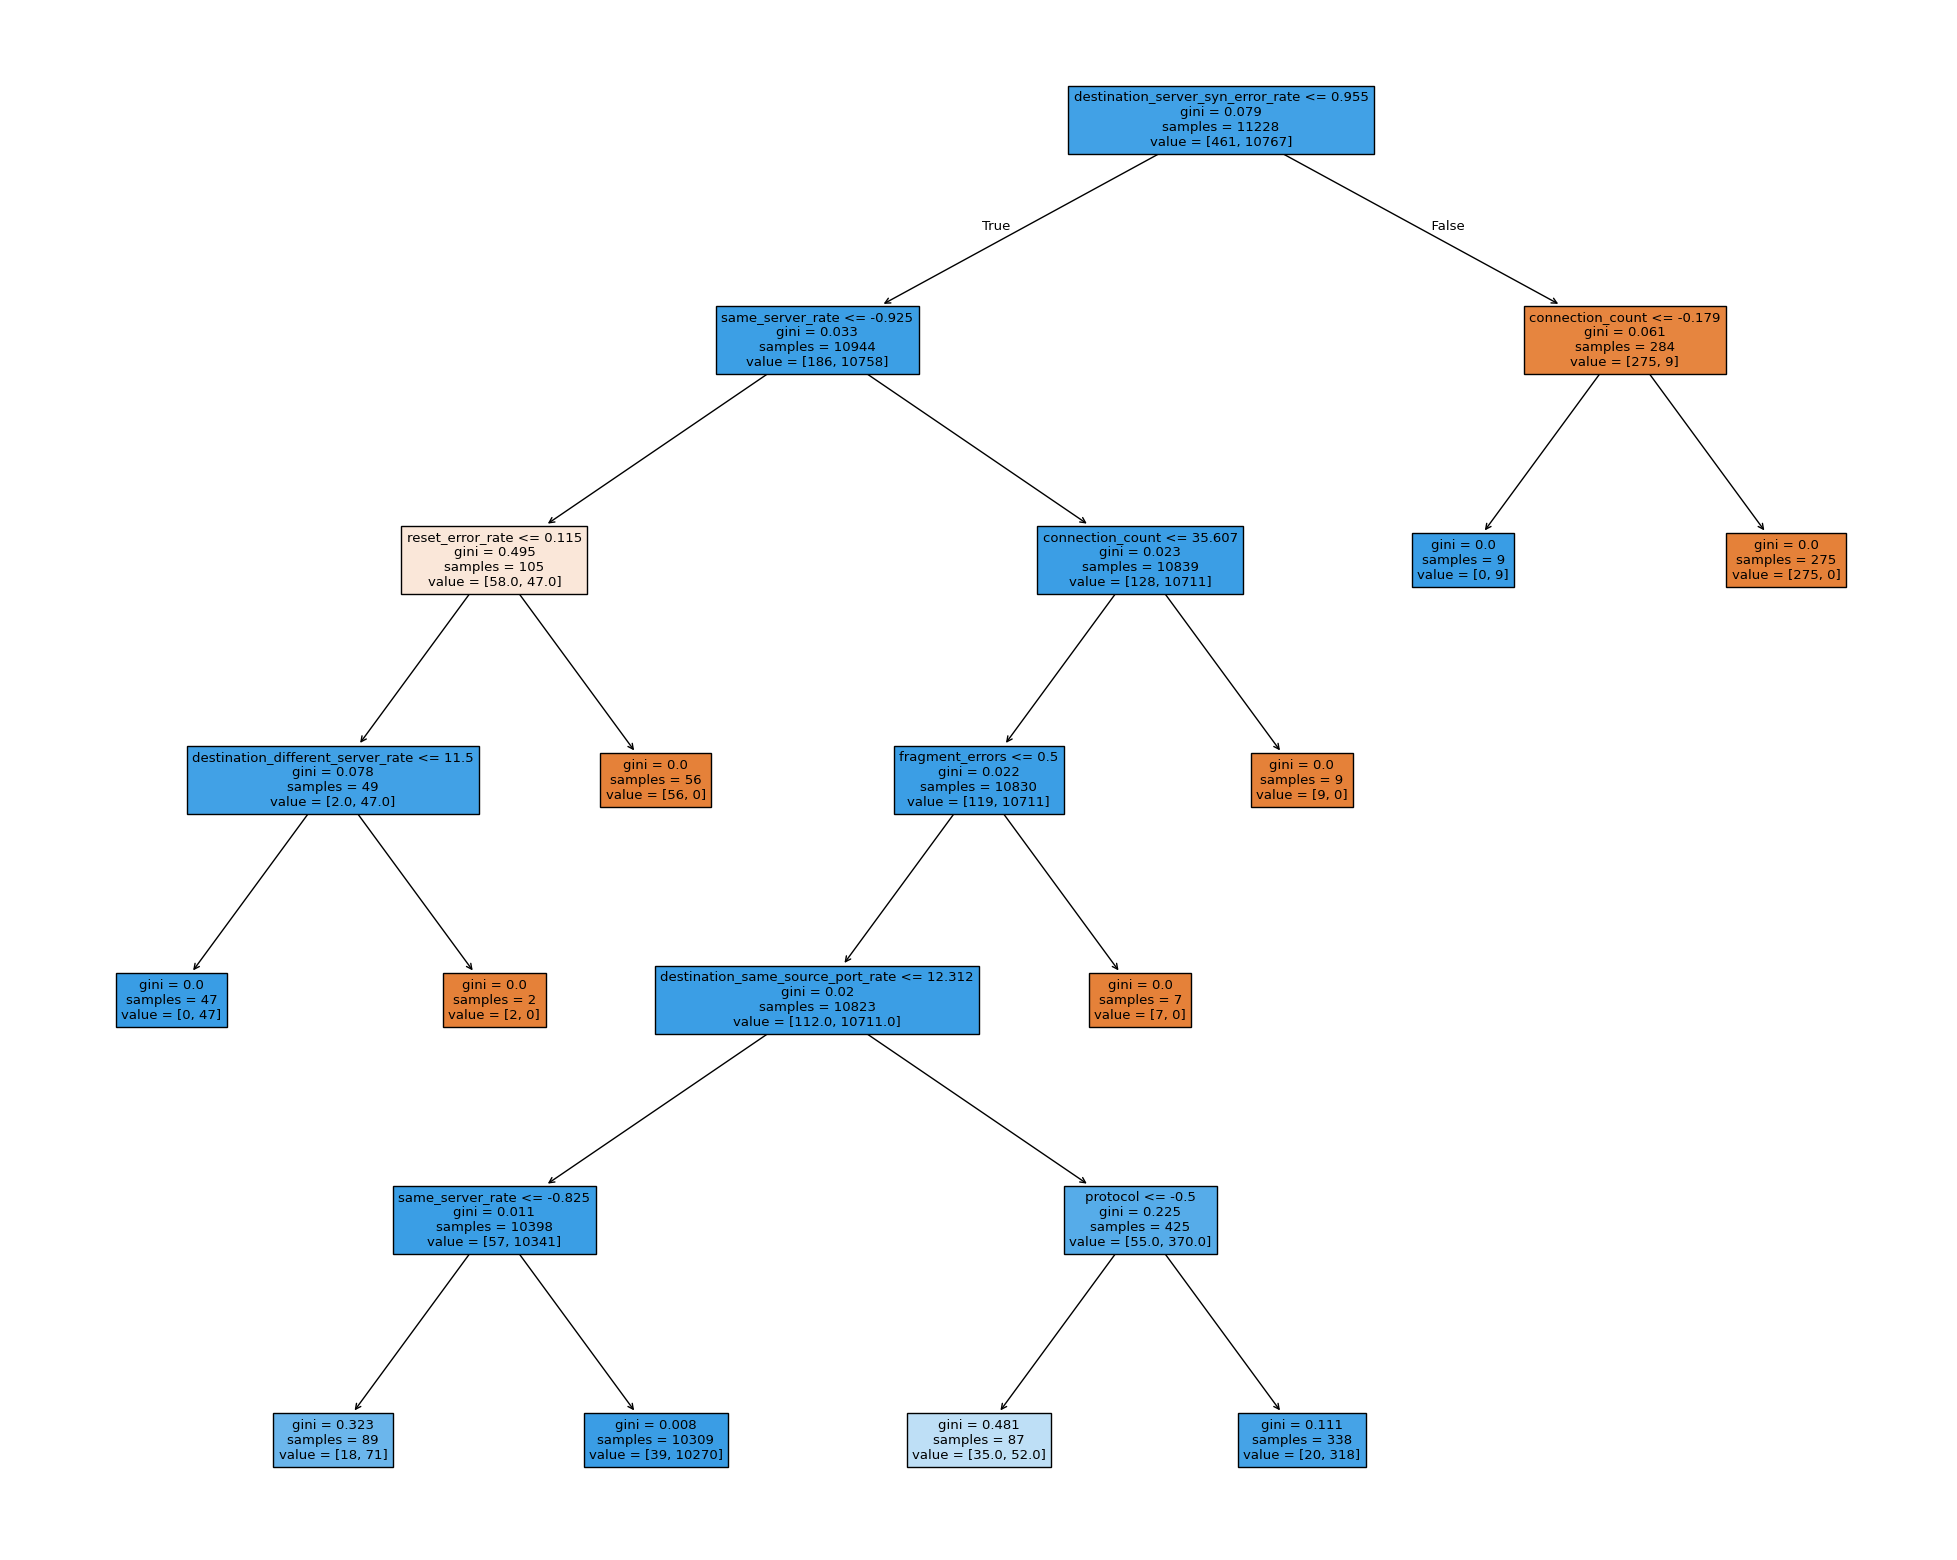

In [298]:
text_representation = tree.export_text(model)

plt.figure(figsize=(25, 20))
input_variables = X.columns
tree.plot_tree(model, feature_names=input_variables, filled=True)

plt.show()

In [299]:
model_pred = model.predict(X_test)
model_accuracy_score = accuracy_score(Y_test, model_pred)
print (model_accuracy_score)

0.988960113960114


In [301]:
base_models = [
    ('SVM', clf),
    ('knn', knn),
    ('decision_tree', model)
]
meta_model = logist
stacking_model = StackingClassifier(estimators=base_models, final_estimator=meta_model , cv = 5)
stacking_model.fit(X_train, Y_train)
Y_pred_stacking = stacking_model.predict(X_test)
accuracy_stacking = accuracy_score(Y_test, Y_pred_stacking)
print('ACC->',accuracy_stacking)

ACC-> 0.9960826210826211


In [302]:
base_models = [
    ('logistic', logist),
    ('knn', knn),
    ('decision_tree', model)
]
meta_model = clf
stacking_model = StackingClassifier(estimators=base_models, final_estimator=meta_model , cv = 5)
stacking_model.fit(X_train, Y_train)
Y_pred_stacking = stacking_model.predict(X_test)
accuracy_stacking = accuracy_score(Y_test, Y_pred_stacking)
print('ACC->',accuracy_stacking)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

ACC-> 0.9946581196581197


In [303]:
# svm more complex negarab el svm heya el meta model

In [304]:
precision_KNN = precision_score(Y_test, Y_pred_model_knn)
recall_KNN = recall_score(Y_test, Y_pred_model_knn)
f1_KNN = f1_score(Y_test, Y_pred_model_knn)
roc_auc_KNN = roc_auc_score(Y_test, Y_pred_model_knn)

print("Precision for KNN:", precision_KNN)
print("Recall for KNN:", recall_KNN)
print("F1 Score for KNN:", f1_KNN)
print("ROC AUC Score for KNN:", roc_auc_KNN)

Precision for KNN: 0.9914909359970403
Recall for KNN: 0.9992542878448919
F1 Score for KNN: 0.9953574744661096
ROC AUC Score for KNN: 0.9083573026526046


In [305]:
precision_logistic = precision_score(Y_test, Y_pred_logistic)
recall_logistic = recall_score(Y_test, Y_pred_logistic)
f1_logistic = f1_score(Y_test, Y_pred_logistic)
roc_auc_logistic = roc_auc_score(Y_test, Y_pred_logistic)

print("Precision for logistic:", precision_logistic)
print("Recall for logistic:", recall_logistic)
print("F1 Score for logistic:", f1_logistic)
print("ROC AUC Score for logistic:", roc_auc_logistic)

Precision for logistic: 0.9933234421364985
Recall for logistic: 0.9985085756897838
F1 Score for logistic: 0.995909259947936
ROC AUC Score for logistic: 0.9278257164163205


In [306]:
precision_decision_tree = precision_score(Y_test, model_pred)
recall_decision_tree = recall_score(Y_test, model_pred)
f1_decision_tree = f1_score(Y_test, model_pred)
roc_auc_decision_tree = roc_auc_score(Y_test, model_pred)

print("Precision for decision tree:", precision_decision_tree)
print("Recall for decision tree:", recall_decision_tree)
print("F1 Score for decision tree:", f1_decision_tree)
print("ROC AUC Score for decision tree:", roc_auc_decision_tree)

Precision for decision tree: 0.9885735348322889
Recall for decision tree: 1.0
F1 Score for decision tree: 0.9942539388322521
ROC AUC Score for decision tree: 0.876984126984127


In [307]:
precision_SVM = precision_score(Y_test, Y_pred_SVM)
recall_SVM = recall_score(Y_test, Y_pred_SVM)
f1_SVM = f1_score(Y_test, Y_pred_SVM)
roc_auc_SVM = roc_auc_score(Y_test, Y_pred_SVM)

print("Precision for SVM:", precision_SVM)
print("Recall for SVM:", recall_SVM)
print("F1 Score for SVM:", f1_SVM)
print("ROC AUC Score for SVM:", roc_auc_SVM)

Precision for SVM: 0.9962825278810409
Recall for SVM: 0.9992542878448919
F1 Score for SVM: 0.9977661950856291
ROC AUC Score for SVM: 0.9599446042399065


In [310]:
# SVM (rbf with C = 10) is the most accurate model with accuracy_score of (0.9957264957264957)